# **Resolución Actividad Semana 2 Fundamentos para IA**
**Dataset:** StudentsPerformance

Objetivo: elaborar un estudio de caso sobre Python para ciencia de datos


# 1. Conectar al drive para cargar el dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2. Cargar el notebook y mostrar: Importación de librerías, lectura del CSV, visualización inicial

In [ ]:
##Importar librerías pandas y matplotlib
import pandas as pd
import matplotlib.pyplot as plt

#Cargar dataset desde el drive
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Data_sets/StudentsPerformance.csv')

*   Verificar que los datos del dataset cargan

In [ ]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# 3. Comprensión de variables (columnas).

In [ ]:
#Tamaño del dataset
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])

#Nombre de las columnas
df.columns

#Tipos de datos
df.dtypes




Número de filas: 1000
Número de columnas: 8


,0
gender,object
race/ethnicity,object
parental level of education,object
lunch,object
test preparation course,object
math score,int64
reading score,int64
writing score,int64


El dataset contiene 1000 filas y 8 columnas.

 - Nombre de las columnas:
   -   gender
   -   race/ethnicity
   -   parental level of education
   -   lunch
   -   test preparation course
   -   math score
   -   reading score
   -   writing score

 - Tipo de datos:
   -   5 variables categóricas: gender, race/ethnicity, parental level of education, lunch, test preparation course
   -   3 variables numéricas: math score, reading score, writing score      

# 4. Calidad de datos

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
Duplicados: 0


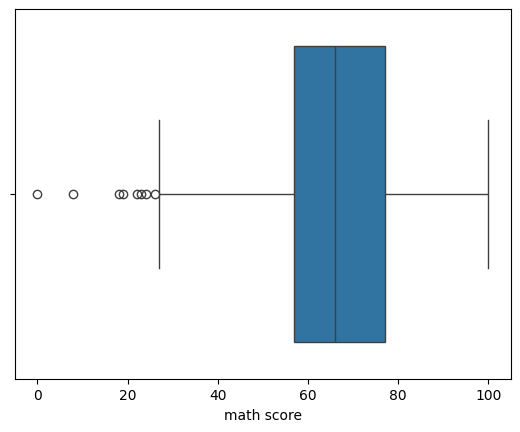

Cantidad de valores atípicos: 8
17     18
59      0
145    22
338    24
466    26
787    19
842    23
980     8
Name: math score, dtype: int64


In [ ]:
# Valores nulos por columna
print(df.isnull().sum())

# Duplicados
print("Duplicados:", df.duplicated().sum())

# Valores atípicos en 'math score'
import seaborn as sns
sns.boxplot(x=df["math score"])
plt.show()

Q1 = df["math score"].quantile(0.25)
Q3 = df["math score"].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

outliers = df[
    (df["math score"] < limite_inferior) |
    (df["math score"] > limite_superior)
]

print("Cantidad de valores atípicos:", len(outliers))
print(outliers["math score"])


 - No se presentan datos nulos
 - No hay duplicados
 - se escoge la variable math score para evaluar valores atípicos. El análisis del diagrama de caja revela que la mayoría de estudiantes se ubica en un rango medio, con la mediana cerca de 66 puntos y la mitad entre 57 y 76. Se destacan algunos casos con puntajes muy bajos que aparecen como valores atípicos. En general, los resultados altos se mantienen dentro de lo esperado, mostrando un desempeño mayormente equilibrado

# 5. Análisis exploratorio inicial

 - Variables categóricas (mínimo 2): Frecuencias y porcentajes por ejemplo:


Frecuencia y porcentaje de género
gender
female    518
male      482
Name: count, dtype: int64
gender
female    51.8
male      48.2
Name: proportion, dtype: float64


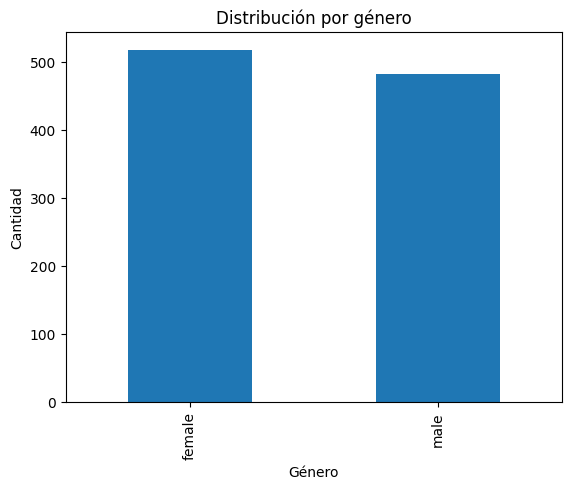


Frecuencia y porcentaje de lunch
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
lunch
standard        64.5
free/reduced    35.5
Name: proportion, dtype: float64


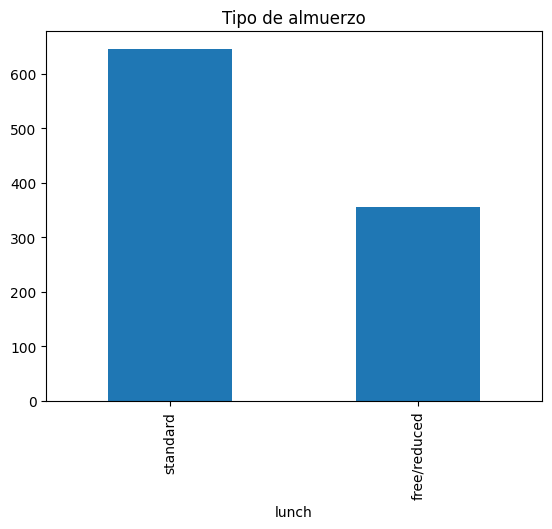


Frecuencia y porcentaje de parental level of education
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
parental level of education
some college          22.6
associate's degree    22.2
high school           19.6
some high school      17.9
bachelor's degree     11.8
master's degree        5.9
Name: proportion, dtype: float64


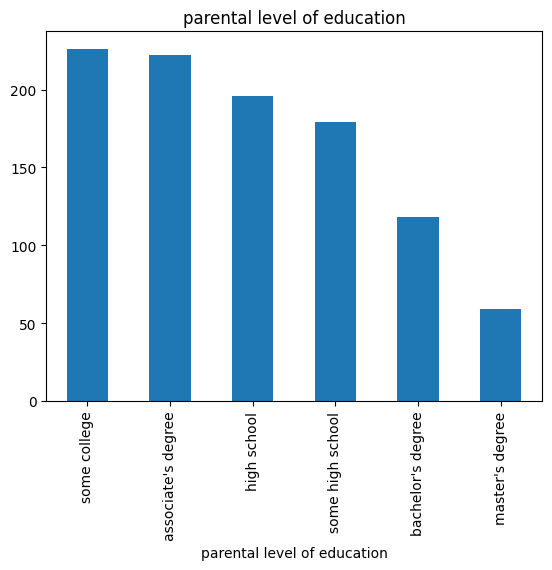


Frecuencia y porcentaje de race/ethnicity
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
race/ethnicity
group C    31.9
group D    26.2
group B    19.0
group E    14.0
group A     8.9
Name: proportion, dtype: float64


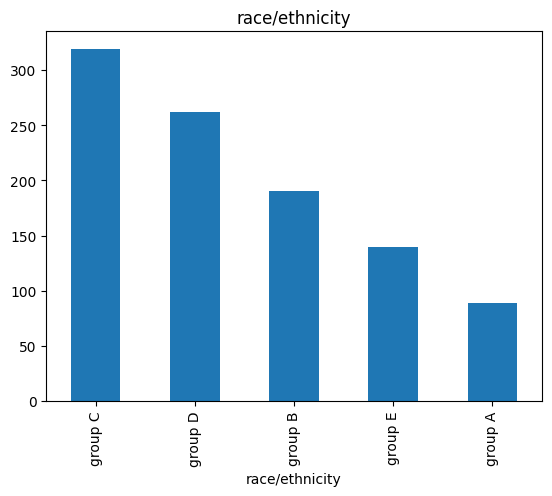


Frecuencia y porcentaje de test preparation course
test preparation course
none         642
completed    358
Name: count, dtype: int64
test preparation course
none         64.2
completed    35.8
Name: proportion, dtype: float64


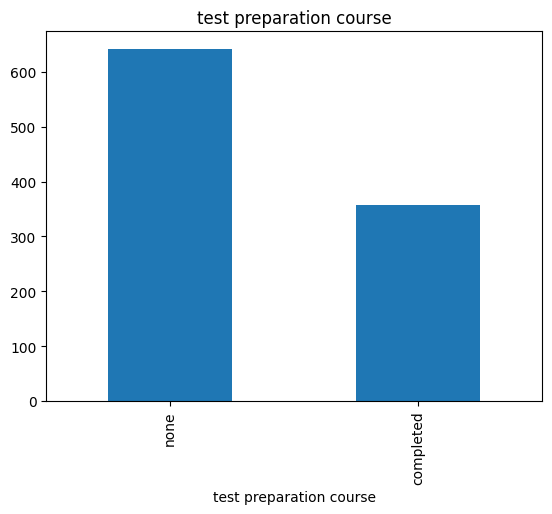

In [ ]:
df["gender"].value_counts(normalize=True)*100


# Frecuencia y porcentaje de variable género
print("\nFrecuencia y porcentaje de género")
print(df["gender"].value_counts())
print(df["gender"].value_counts(normalize=True) * 100)

df["gender"].value_counts().plot(kind="bar")
plt.title("Distribución por género")
plt.xlabel("Género")
plt.ylabel("Cantidad")
plt.show()

# Frecuencia y porcentaje de variable lunch
print("\nFrecuencia y porcentaje de lunch")
print(df["lunch"].value_counts())
print(df["lunch"].value_counts(normalize=True) * 100)

df["lunch"].value_counts().plot(kind="bar")
plt.title("Tipo de almuerzo")
plt.show()


# Frecuencia y porcentaje de variable parental level of education
print("\nFrecuencia y porcentaje de parental level of education")
print(df["parental level of education"].value_counts())
print(df["parental level of education"].value_counts(normalize=True) * 100)

df["parental level of education"].value_counts().plot(kind="bar")
plt.title("parental level of education")
plt.show()


# Frecuencia y porcentaje de variable parental race/ethnicity
print("\nFrecuencia y porcentaje de race/ethnicity")
print(df["race/ethnicity"].value_counts())
print(df["race/ethnicity"].value_counts(normalize=True) * 100)

df["race/ethnicity"].value_counts().plot(kind="bar")
plt.title("race/ethnicity")
plt.show()

# Frecuencia y porcentaje de variable test preparation course
print("\nFrecuencia y porcentaje de test preparation course")
print(df["test preparation course"].value_counts())
print(df["test preparation course"].value_counts(normalize=True) * 100)

df["test preparation course"].value_counts().plot(kind="bar")
plt.title("test preparation course")
plt.show()


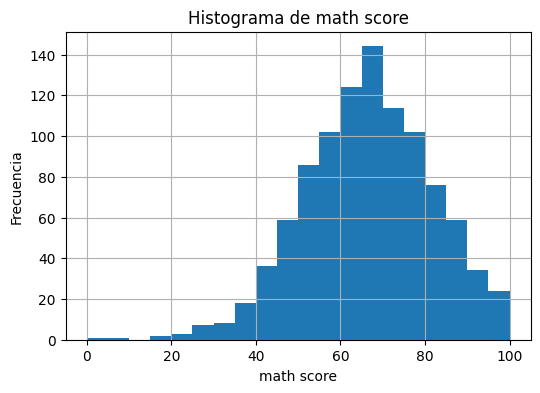

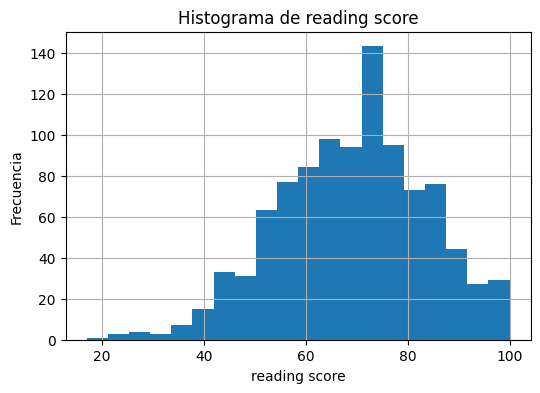

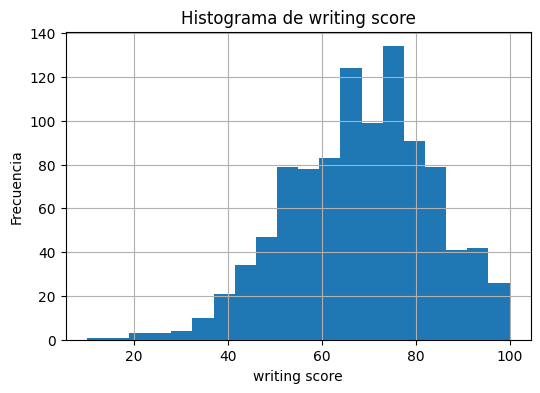

In [ ]:
#Histogramas para observar la distribución de variables numéricas

variables = ["math score","reading score","writing score"]

for var in variables:

    plt.figure(figsize=(6,4))

    plt.hist(df[var], bins=20)

    plt.title(f"Histograma de {var}")

    plt.xlabel(var)

    plt.ylabel("Frecuencia")

    plt.grid()

    plt.show()

 - Variables numéricas (mínimo 2) : Medidas: media, mediana, min, max,
desviación:

In [ ]:
# Estadísticas descriptivas de math y reading score
print("math score")
print(df["math score"].describe())

print("\nreading score")
print(df["reading score"].describe())


math score
count    1000.00000
mean       66.08900
std        15.16308
min         0.00000
25%        57.00000
50%        66.00000
75%        77.00000
max       100.00000
Name: math score, dtype: float64

reading score
count    1000.000000
mean       69.169000
std        14.600192
min        17.000000
25%        59.000000
50%        70.000000
75%        79.000000
max       100.000000
Name: reading score, dtype: float64


# 6. Preguntas para el informe final

 - **¿Qué fenómeno, proceso o contexto representa el dataset?**
  
 El dataset representa el desempeño académico de 1000 estudiantes en las pruebas de matemáticas, lectura y escritura. Además, incluye variables demográficas y socioeducativas como el género, el grupo étnico, el nivel educativo de los padres, el tipo de almuerzo recibido y la realización de un curso de preparación para el examen

 - **¿Cuáles son las 5 variables más importantes para describir el caso y por
qué?**

1. **Math score**: mide el rendimiento en matemáticas.
2. **Reading score**: permite evaluar la comprensión lectora.
3. **Writing score**: refleja las habilidades de escritura.
4. **Test preparation course**: ayuda a analizar el impacto de la preparación previa sobre el rendimiento.
5. **Parental level of education**: permite estudiar la influencia del nivel educativo de los padres en el desempeño académico.

 - **¿Qué hallazgos se observan en la distribución de variables (categóricas y
numéricas)?**
   -   Las variables categóricas presentan una distribución relativamente equilibrada entre hombres y mujeres.
   -   La mayoría de los estudiantes tuvieron almuerzo estándar.
   -   Los puntajes numéricos muestran una distribución aproximadamente normal.
   -   Lectura y escritura presentan una alta relación positiva.
   -   Matemáticas también está relacionada con lectura y escritura, aunque en menor medida.

 - **¿Qué relación relevante encontraron entre las variables? (mínimo 2)**
   -   Existe una fuerte correlación positiva entre los puntajes de lectura y escritura, indicando que los estudiantes con mejor comprensión lectora suelen obtener mejores resultados en escritura.
   -   Los estudiantes que realizaron el curso de preparación generalmente presentan puntajes superiores respecto a quienes no lo realizaron.  

 - **¿Qué problemas de calidad de datos detectaron y cómo los abordan?**
   -   Se detectan algunos valores atípicos en los puntajes mediante diagramas de caja; sin embargo, estos pueden representar estudiantes con rendimientos excepcionalmente altos o bajos y no necesariamente errores de registro.

  -  **Con base en lo observado: ¿qué pregunta de IA o problema predictivo
podría plantearse a futuro con este dataset? (ej: clasificación, regresión,
clustering)**

    -    ¿Podemos predecir el puntaje de escritura a partir de género, almuerzo y preparación?